In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_non_bonded_potential_energy)=
# Get non-bonded potential energy

*Calculating non-bonded (electrostatic and van der Waals) interaction energies between selections.*

The function {func}`molsysmt.molecular_mechanics.get_non_bonded_potential_energy` computes non-bonded interaction energies across molecular interfaces or evaluates residue-by-residue interaction energy matrices.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.molecular_mechanics.get_non_bonded_potential_energy`.
:::


## Basic usage

Let's compute the non-bonded interaction energy across a protein–protein complex interface:


In [2]:
import molsysmt as msm
import pyunitwizard as puw
import matplotlib.pyplot as plt
import numpy as np


In [3]:
molsys = msm.convert(msm.systems['Barnase-Barstar']['barnase_barstar.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We calculate the total non-bonded interaction energy between Barnase and Barstar:


In [4]:
u_nb = msm.molecular_mechanics.get_non_bonded_potential_energy(molsys,
                                                              selection='molecule_name=="BARNASE"',
                                                              selection_2='molecule_name=="BARSTAR"')
print('Total non-bonded interaction energy:', u_nb)


Total non-bonded interaction energy: -3162.292497634964 kilojoule / mole


## Pairwise residue interaction energy matrix

Passing lists of atom selections (e.g. for each residue in the respective molecules) yields the complete inter-residue interaction energy matrix:


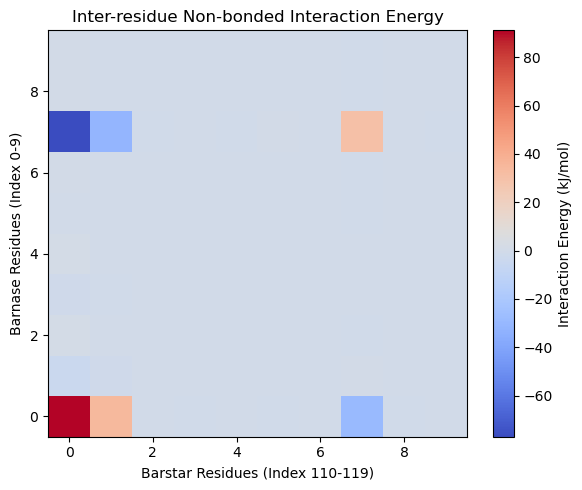

In [5]:
barnase_groups = [msm.select(molsys, selection=f'molecule_name=="BARNASE" and group_index=={ii}') for ii in range(10)]
barstar_groups = [msm.select(molsys, selection=f'molecule_name=="BARSTAR" and group_index=={jj}') for jj in range(110, 120)]

u_matrix = msm.molecular_mechanics.get_non_bonded_potential_energy(molsys, selection=barnase_groups, selection_2=barstar_groups)
u_vals = puw.get_value(u_matrix, to_unit='kJ/mol')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(u_vals, origin='lower', cmap='coolwarm', aspect='auto')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Interaction Energy (kJ/mol)')
ax.set_title('Inter-residue Non-bonded Interaction Energy')
ax.set_xlabel('Barstar Residues (Index 110-119)')
ax.set_ylabel('Barnase Residues (Index 0-9)')
plt.tight_layout()
plt.show()


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems with {func}`molsysmt.basic.convert`.
- {ref}`Select <Tutorial_Select>`: Query atom selections with {func}`molsysmt.basic.select`.
- {ref}`Get potential energy <Tutorial_Get_potential_energy>`: Calculate total potential energy with {func}`molsysmt.molecular_mechanics.get_potential_energy`.
:::
